In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [2]:
# device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
# Download data
ticker = 'AAPL'
df = yf.download(ticker,start='2020-01-01', end='2026-08-7')

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400
2020-01-03,71.630623,72.389242,71.406651,71.563190,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


In [5]:
df.shape

(1657, 5)

In [6]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1657 entries, 2020-01-02 to 2026-08-06
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1657 non-null   float64
 1   (High, AAPL)    1657 non-null   float64
 2   (Low, AAPL)     1657 non-null   float64
 3   (Open, AAPL)    1657 non-null   float64
 4   (Volume, AAPL)  1657 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.7 KB


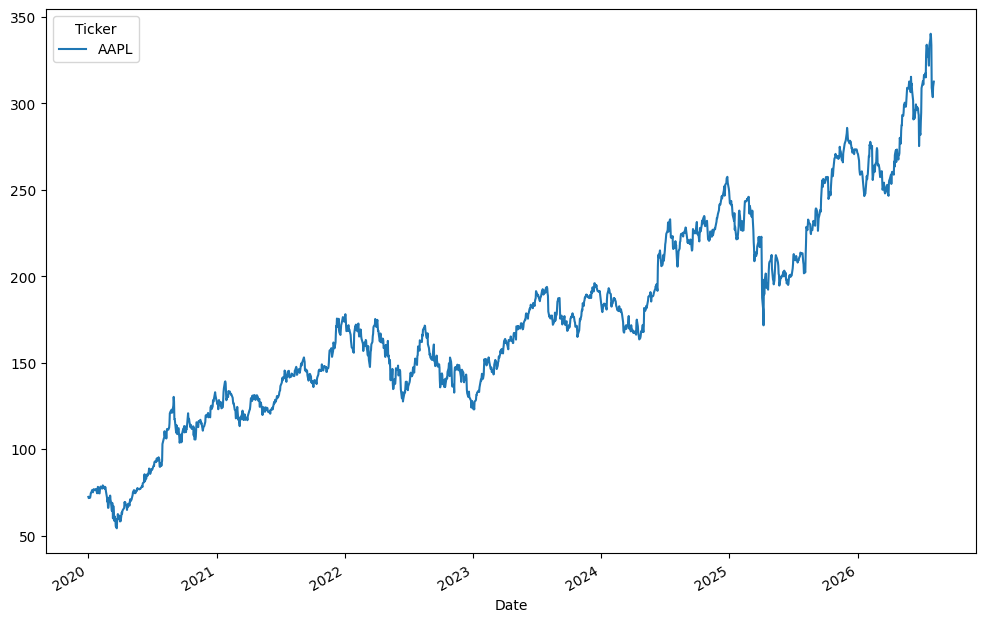

In [8]:
# we are only intersted in Colse
df.Close.plot(figsize=(12,8))
plt.show()

In [9]:
scalar = StandardScaler()
df["Close"] = scalar.fit_transform(df["Close"])

In [10]:
df.Close.head()

Ticker,AAPL
Date,
2020-01-02,-1.759936
2020-01-03,-1.771977
2020-01-06,-1.762204
2020-01-07,-1.768018
2020-01-08,-1.748225


In [11]:
seq_length = 30
data = []

for i in range(len(df)-seq_length):
    data.append(df.Close[i:i+seq_length])
data = np.array(data)

In [12]:
#data

In [13]:
data.shape

(1627, 30, 1)

In [14]:
# create training and testing data

train_size = int(0.8*len(data))
# in 1 sequence 29 instances are traing and last instance is for prediction means y.
X_train = torch.from_numpy(data[:train_size,:-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:,:-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [15]:
X_train.shape, y_train.shape

(torch.Size([1301, 29, 1]), torch.Size([1301, 1]))

In [16]:
# Model
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            batch_first = True
        )
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = out[:,-1,:]
        out = self.fc(out)
        return out

In [17]:
model = PredictionModel(
    input_dim=1,
    hidden_dim=64,
    num_layers=2,
    output_dim=1
).to(device)

In [18]:
criterion = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr = 1e-2
)

In [19]:
# Model training
epochs = 200
for epoch in range(epochs):
    model.train()
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1)%25 ==0:
        print(f"Epoch [{epoch}/{epochs}] Loss : {loss.item()}")

Epoch [24/200] Loss : 0.014899373054504395
Epoch [49/200] Loss : 0.005235892254859209
Epoch [74/200] Loss : 0.004516725894063711
Epoch [99/200] Loss : 0.004150338936597109
Epoch [124/200] Loss : 0.0038601651322096586
Epoch [149/200] Loss : 0.0035892664454877377
Epoch [174/200] Loss : 0.003320062533020973
Epoch [199/200] Loss : 0.0030837717931717634


In [20]:
# Model evaluation
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)

y_test_pred = scalar.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scalar.inverse_transform(y_test.detach().cpu().numpy())
y_train_pred = scalar.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scalar.inverse_transform(y_train.detach().cpu().numpy())

In [21]:
train_rmse = root_mean_squared_error(y_train[:,0], y_train_pred[:,0])
test_rmse = root_mean_squared_error(y_test[:,0], y_test_pred[:,0])
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")

Test RMSE: 5.0732
Train RMSE: 3.2433


In [22]:
df.shape, len(y_test)

((1657, 5), 326)

In [23]:
df.iloc[-len(y_test):]

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-04-21,0.291436,192.781396,188.812362,192.254183,46742500
2025-04-22,0.403505,200.530453,194.939996,195.089202,52976400
2025-04-23,0.486279,206.906751,201.734085,204.917263,52929200
2025-04-24,0.550489,207.732400,201.873358,203.813106,47311000
2025-04-25,0.565987,208.647554,205.116210,205.285315,38222300
...,...,...,...,...,...
2026-07-31,2.290661,310.690002,300.000000,304.809998,132489100
2026-08-03,2.196663,311.799988,302.559998,309.579987,75052000


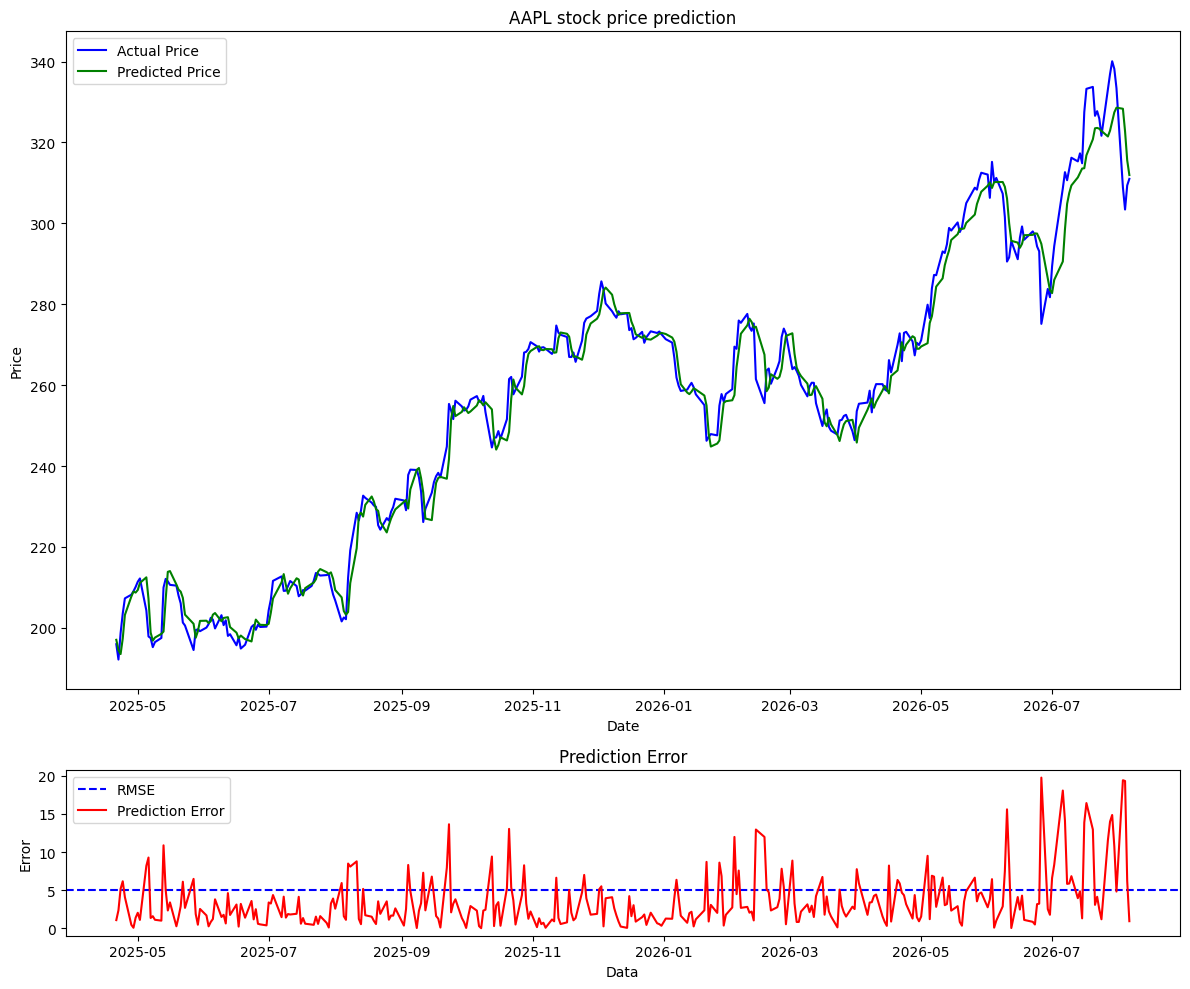

In [25]:
fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(4,1)

ax1 = fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label = "Actual Price")
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label = "Predicted Price")
ax1.legend()
plt.title(f"{ticker} stock price prediction")
plt.xlabel("Date")
plt.ylabel("Price")

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color="blue", linestyle ='--', label="RMSE")
ax2.plot(df.iloc[-len(y_test):].index, abs(y_test-y_test_pred),'r',label ="Prediction Error")
ax2.legend()
plt.title("Prediction Error")
plt.xlabel("Data")
plt.ylabel("Error")
plt.tight_layout()
plt.show()